### **1. Data Extraction & Cleaning**

In [ ]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

In [ ]:
superstore = pd.read_csv('Superstore-Dataset.csv', encoding='latin1')
superstore.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [ ]:
# delete row
df = superstore.drop(columns=['Row ID','Order ID','Customer ID','Customer Name','Postal Code'])

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 16 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Order Date    9994 non-null   string 
 1   Ship Date     9994 non-null   string 
 2   Ship Mode     9994 non-null   string 
 3   Segment       9994 non-null   string 
 4   Country       9994 non-null   string 
 5   City          9994 non-null   string 
 6   State         9994 non-null   string 
 7   Region        9994 non-null   string 
 8   Product ID    9994 non-null   string 
 9   Category      9994 non-null   string 
 10  Sub-Category  9994 non-null   string 
 11  Product Name  9994 non-null   string 
 12  Sales         9994 non-null   Float64
 13  Quantity      9994 non-null   Int64  
 14  Discount      9994 non-null   Float64
 15  Profit        9994 non-null   Float64
dtypes: Float64(3), Int64(1), string(12)
memory usage: 1.3 MB


In [ ]:
df = df.convert_dtypes()
df['Category'] = df['Category'].astype('category')
df['Sub-Category'] = df['Sub-Category'].astype('category')
df = df.rename(columns={'Sales':'Price'})

In [ ]:
df.describe()

,Sales,Quantity,Discount,Profit
count,9994.0,9994.0,9994.0,9994.0
mean,229.858001,3.789574,0.156203,28.656896
std,623.245101,2.22511,0.206452,234.260108
min,0.444,1.0,0.0,-6599.978
25%,17.28,2.0,0.0,1.72875
50%,54.49,3.0,0.2,8.6665
75%,209.94,5.0,0.2,29.364
max,22638.48,14.0,0.8,8399.976


##### Although 'Sales' and 'Profit' show extreme values, they represent real business transactions rather than data errors, so they were retained for analysis.

In [ ]:
df.head()

,Order Date,Ship Date,Ship Mode,Segment,Country,City,State,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,11/8/2016,11/11/2016,Second Class,Consumer,United States,Henderson,Kentucky,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.96,2,0.0,41.9136
1,11/8/2016,11/11/2016,Second Class,Consumer,United States,Henderson,Kentucky,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.94,3,0.0,219.582
2,6/12/2016,6/16/2016,Second Class,Corporate,United States,Los Angeles,California,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.62,2,0.0,6.8714
3,10/11/2015,10/18/2015,Standard Class,Consumer,United States,Fort Lauderdale,Florida,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.031
4,10/11/2015,10/18/2015,Standard Class,Consumer,United States,Fort Lauderdale,Florida,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.368,2,0.2,2.5164


### **2. Correlation Heatmap & Profit by Type**

In [ ]:
df_num = df.select_dtypes(include='number')
df_num.corr()

,Sales,Quantity,Discount,Profit
Sales,1.000000,0.200795,-0.028190,0.479064
Quantity,0.200795,1.000000,0.008623,0.066253
Discount,-0.028190,0.008623,1.000000,-0.219487
Profit,0.479064,0.066253,-0.219487,1.000000


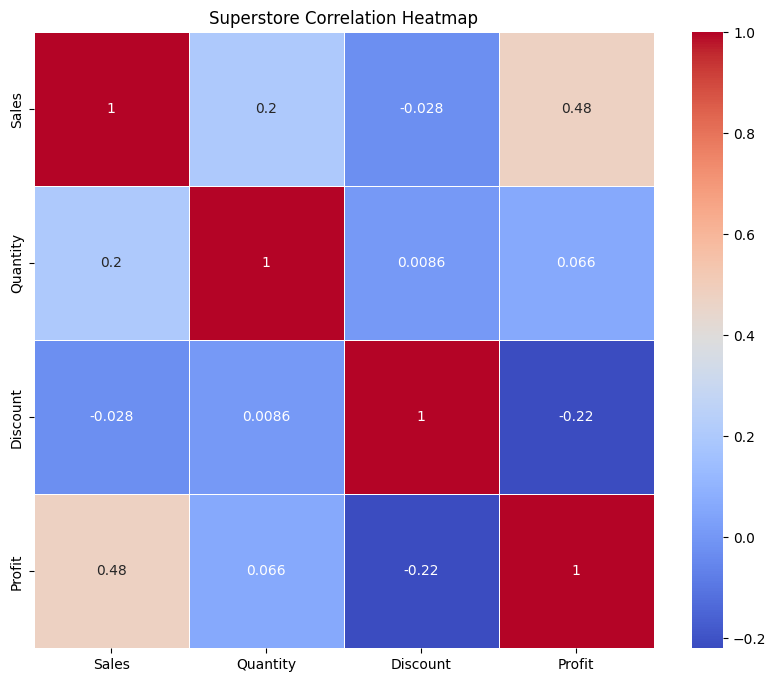

In [ ]:
plt.figure(figsize=(10,8))
plt.title('Superstore Correlation Heatmap')
sns.heatmap(df_num.corr(), annot=True, linewidth=.5, cmap='coolwarm')
plt.show()

The analysis shows that sales is the strongest driver of profit, with a moderate positive correlation (0.48), indicating that increasing revenue directly improves business performance.

Discount has a negative correlation with profit (-0.22), suggesting that excessive discounting reduces profitability and should be applied strategically rather than broadly.

Quantity has only a weak relationship with profit (0.066), implying that selling more units alone does not necessarily increase earnings unless supported by strong pricing and margin control.

Overall, the results highlight that optimizing pricing strategy and controlling discount levels are more impactful for improving profitability than increasing sales volume alone.

In [ ]:
df.groupby('Category')['Profit'].sum().sort_values()

/tmp/ipykernel_5154/1944705238.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('Category')['Profit'].sum().sort_values()


,Profit
Category,
Furniture,18451.2728
Office Supplies,122490.8008
Technology,145454.9481


In [ ]:
df.groupby('Sub-Category')['Profit'].sum().sort_values()

/tmp/ipykernel_5154/2693124249.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('Sub-Category')['Profit'].sum().sort_values()


,Profit
Sub-Category,
Tables,-17725.4811
Bookcases,-3472.556
Supplies,-1189.0995
Fasteners,949.5182
Machines,3384.7569
Labels,5546.254
Art,6527.787
Envelopes,6964.1767
Furnishings,13059.1436


In [ ]:
df.groupby('Region')['Price'].sum()

,Price
Region,
Central,501239.8908
East,678781.24
South,391721.905
West,725457.8245


In [ ]:
df.groupby('Segment')['Profit'].sum().sort_values()

,Profit
Segment,
Home Office,60298.6785
Corporate,91979.134
Consumer,134119.2092


### **3. Linear Regression Model**


In [ ]:
df.sample()

,Order Date,Ship Date,Ship Mode,Segment,Country,City,State,Region,Product ID,Category,Sub-Category,Product Name,Price,Quantity,Discount,Profit
465,4/22/2016,4/29/2016,Standard Class,Home Office,United States,Phoenix,Arizona,West,OFF-SU-10003505,Office Supplies,Supplies,Premier Electric Letter Opener,185.376,2,0.2,-34.758


In [ ]:
# Convert Categorical data to Numeric
df_encode = pd.get_dummies(df,columns = ['Segment', 'Region', 'Category','Sub-Category'], drop_first = True, dtype='int')
df_encode.sample()

,Order Date,Ship Date,Ship Mode,Country,City,State,Product ID,Product Name,Price,Quantity,...,Sub-Category_Envelopes,Sub-Category_Fasteners,Sub-Category_Furnishings,Sub-Category_Labels,Sub-Category_Machines,Sub-Category_Paper,Sub-Category_Phones,Sub-Category_Storage,Sub-Category_Supplies,Sub-Category_Tables
4768,6/2/2017,6/3/2017,Same Day,United States,Jacksonville,North Carolina,OFF-PA-10004733,Things To Do Today Spiral Book,25.344,4,...,0,0,0,0,0,1,0,0,0,0


In [ ]:
# Whole Dataset
X = df_encode.select_dtypes(include=['int64','float64']).drop(columns=['Profit'])
y = df_encode['Profit']

X = X.astype(float)
X = sm.add_constant(X)
model = sm.OLS(y, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                 Profit   R-squared:                       0.336
Model:                            OLS   Adj. R-squared:                  0.334
Method:                 Least Squares   F-statistic:                     210.0
Date:                Tue, 14 Apr 2026   Prob (F-statistic):               0.00
Time:                        21:07:04   Log-Likelihood:                -66668.
No. Observations:                9994   AIC:                         1.334e+05
Df Residuals:                    9969   BIC:                         1.336e+05
Df Model:                          24                                         
Covariance Type:            nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
const                   

In [ ]:
# Exclude insignificant features based on P-value
X = df_encode.select_dtypes(include=['int64','float64']).drop(columns=['Profit', 'Segment_Corporate', 'Segment_Home Office',
                                                                       'Sub-Category_Art', 'Sub-Category_Chairs', 'Sub-Category_Envelopes', 'Sub-Category_Fasteners',
                                                                       'Sub-Category_Labels', 'Sub-Category_Phones', 'Sub-Category_Appliances','Sub-Category_Paper'])
y = df_encode['Profit']
X = X.astype(float)
X = sm.add_constant(X)
model = sm.OLS(y, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                 Profit   R-squared:                       0.335
Model:                            OLS   Adj. R-squared:                  0.334
Method:                 Least Squares   F-statistic:                     314.6
Date:                Tue, 14 Apr 2026   Prob (F-statistic):               0.00
Time:                        21:31:30   Log-Likelihood:                -66671.
No. Observations:                9994   AIC:                         1.334e+05
Df Residuals:                    9977   BIC:                         1.335e+05
Df Model:                          16                                         
Covariance Type:            nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
const                   

### **4. Model Evaluation (Train/Test)**


In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state = 42)

X_train = sm.add_constant(X_train)
X_test = sm.add_constant(X_test)

model = sm.OLS(y_train, X_train).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                 Profit   R-squared:                       0.444
Model:                            OLS   Adj. R-squared:                  0.442
Method:                 Least Squares   F-statistic:                     348.0
Date:                Tue, 14 Apr 2026   Prob (F-statistic):               0.00
Time:                        22:04:38   Log-Likelihood:                -46078.
No. Observations:                6995   AIC:                         9.219e+04
Df Residuals:                    6978   BIC:                         9.231e+04
Df Model:                          16                                         
Covariance Type:            nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
const                   

The regression results indicate that Price has a strong positive relationship with Profit, while Discount negatively impacts profitability. Several sub-categories also show statistically significant influence on profit performance.

The model achieved an **R-squared** value of approximately **0.44**, indicating that the selected variables explain a moderate proportion of variation in profit.

In [ ]:
y_pred = model.predict(X_test)
y_pred.sample(5)

,0
8722,-104.406477
3578,-9.500029
1472,27.902285
5067,18.013566
965,35.290870


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("R-squared:", r2)
print("MAE:", mae)
print("RMSE:", rmse)

R-squared: -0.03775788774278377
MAE: 64.11387846973504
RMSE: 235.66033265644487


The regression model produced a **MAE** of approximately **64.11**, meaning that **predicted profit** values **differ** from actual outcomes by **around 64** per transaction on average.

**RMSE** accounted for **235.66** indicates the presence of larger prediction errors in certain cases

The **negative R-squared score (-0.03)** on the testing dataset suggests that the model **does not generalize** well to unseen data, highlighting the complexity of profit prediction in retail environment and the need for additional feature engineering or alternative modeling approaches.


### **5. Business Recommendations** ⭐


Based on the analysis, the company should:

1. Optimize **discount policies** across **underperforming sub-categories,** particularly **Tables, Bookcases, and Supplies**, where high discount levels contribute to negative profit

2. Reassess **pricing strategies** for the **Furniture** category, especially in the **Central region**

3. Expand **focus** on high-margin categories such as **Technology** to further improve overall profitability

4. Shift strategic emphasis from **volume-driven growth** toward **margin-driven performance** improvement

5. Monitor sales performance **across regions** to identify underperforming areas and **adjust pricing** or **discount strategies** accordingly

